In [1]:
%pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
sys.path.append("..")

from features.preprocessing import extract_target
from features.text_features import clean_series

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/yurkevychann/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/yurkevychann/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yurkevychann/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/yurkevychann/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
import joblib
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pipeline = joblib.load("../models_results/XGBoost/pipeline.joblib")
label_encoder = joblib.load("../models_results/XGBoost/label_encoder.joblib")
test_df = pd.read_csv("../test.csv")

X_test, y_test = extract_target(test_df, 'Company response to consumer')
y_test_encoded = label_encoder.transform(y_test)

In [5]:
importances = pipeline.named_steps['clf'].feature_importances_
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

In [6]:

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
feature_importance_df.head(30)

,Feature,Importance
10034,categorical__Sub-product_Credit reporting,0.021654
5725,text__looked,0.016817
10001,categorical__Product_Checking or savings account,0.015404
10170,categorical__Company_ENCORE CAPITAL GROUP INC.,0.013337
1757,text__began,0.012760
4182,text__fill,0.012714
5603,text__liable,0.010442
5390,text__kind,0.009956
10178,categorical__Company_Portfolio Recovery Associ...,0.009462
10186,numeric__year,0.009390


In [8]:
sample_size = 300
X_test_sample = X_test.sample(sample_size, random_state=42)

X_test_transformed = pipeline.named_steps['preprocessing'].transform(X_test_sample)

explainer = shap.TreeExplainer(pipeline.named_steps['clf'])
shap_values = explainer.shap_values(X_test_transformed)

/opt/anaconda3/envs/ml/lib/python3.11/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


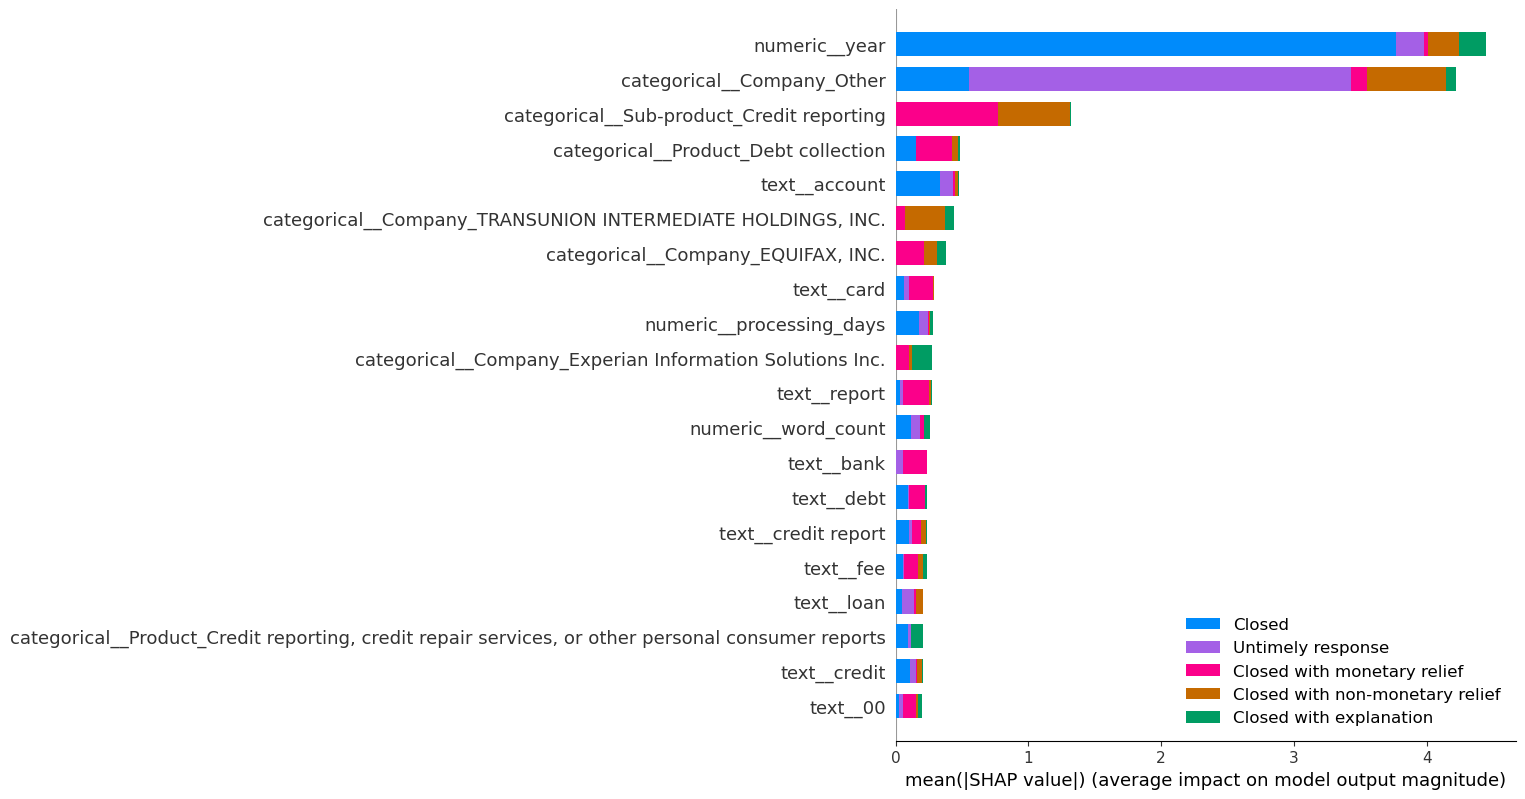

In [11]:
shap.summary_plot(
    shap_values, X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    class_names=label_encoder.classes_,
    max_display=20,
    show=False 
)

plt.savefig("../images/shap_summary_plot.png", dpi=200, bbox_inches='tight')
plt.show()

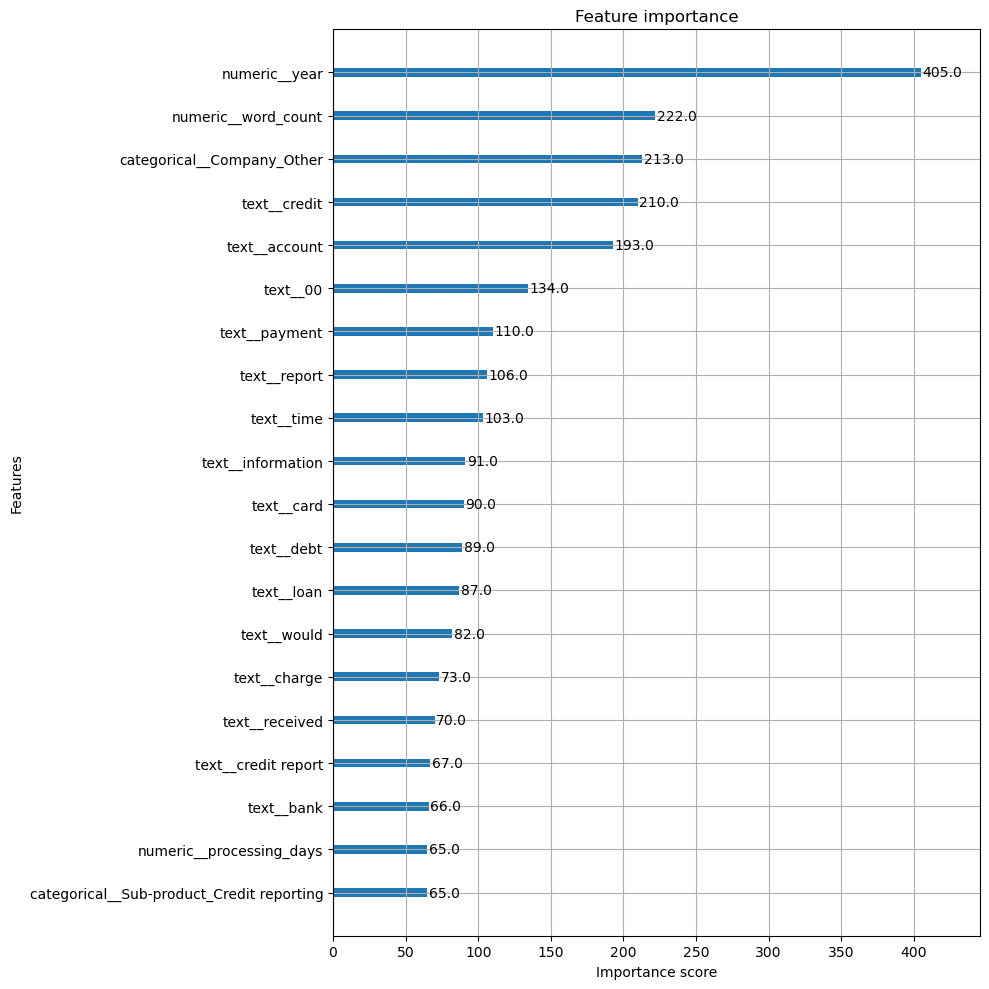

In [18]:
# feature importance with XGBoost
from xgboost import plot_importance

clf = pipeline.named_steps['clf']
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

clf.get_booster().feature_names = list(feature_names)

fig, ax = plt.subplots(figsize=(10, 10))
plot_importance(clf, max_num_features=20, ax=ax)
plt.tight_layout()
fig.savefig("../images/feature_importance.png", dpi=200, bbox_inches='tight')
plt.show()

In [19]:
print(f"Total input features: {len(feature_names)}")

Total input features: 10187


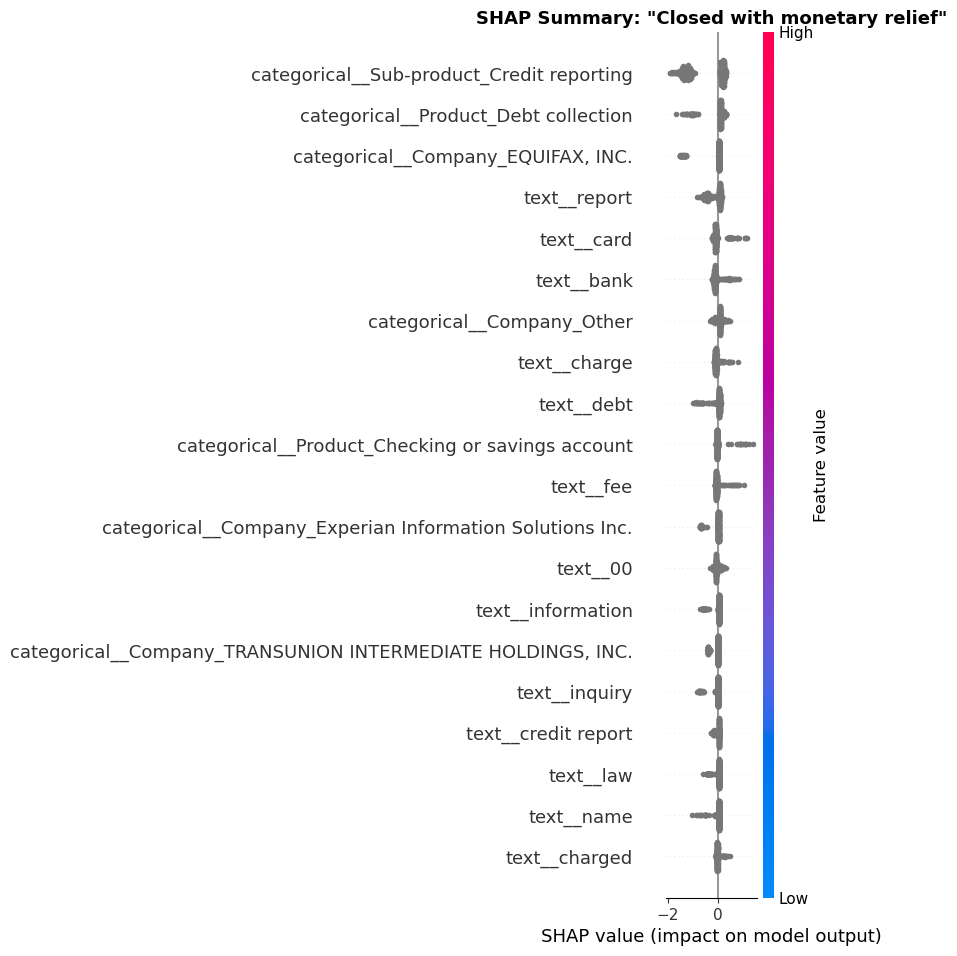

In [13]:
target_class = "Closed with monetary relief"
class_idx = list(label_encoder.classes_).index(target_class)

shap.summary_plot(
    shap_values[:, :, class_idx], 
    X_test_transformed,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title(f'SHAP Summary: "{target_class}"', fontsize=13, fontweight='bold')
plt.savefig(f"../images/shap_summary_{target_class.replace(' ', '_')}.png",
            dpi=200, bbox_inches='tight')
plt.show()

Misclassified: 86 / 300 in this sample
Row 0: predicted 'Closed with non-monetary relief', actual 'Closed with explanation'


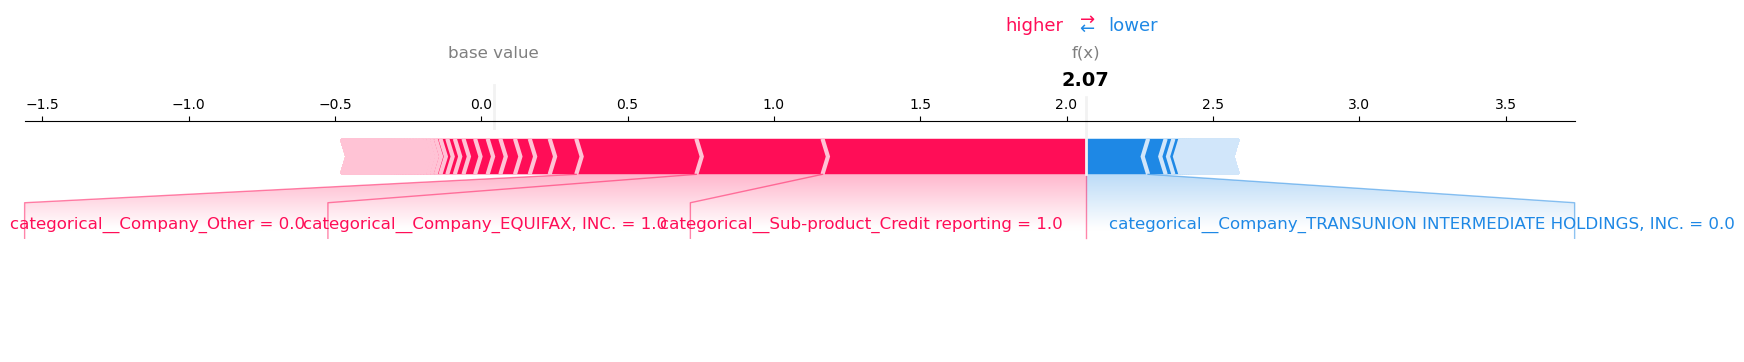

In [14]:
predictions_sample = pipeline.named_steps['clf'].predict(X_test_transformed)
true_labels_sample = label_encoder.transform(y_test.loc[X_test_sample.index])

misclassified_mask = predictions_sample != true_labels_sample
misclassified_positions = np.where(misclassified_mask)[0]

print(f"Misclassified: {misclassified_mask.sum()} / {len(predictions_sample)} in this sample")

if len(misclassified_positions) > 0:
    i = misclassified_positions[0]
    predicted_idx = predictions_sample[i]
    predicted_class = label_encoder.classes_[predicted_idx]
    actual_class = label_encoder.classes_[true_labels_sample[i]]
    print(f"Row {i}: predicted '{predicted_class}', actual '{actual_class}'")

    shap.initjs()
    shap.force_plot(
        explainer.expected_value[predicted_idx],
        shap_values[i, :, predicted_idx],   
        pd.DataFrame(
            X_test_transformed[i:i+1].toarray() if hasattr(X_test_transformed, "toarray")
            else X_test_transformed[i:i+1],
            columns=feature_names
        ),
        matplotlib=True,
        show=False
    )
    plt.savefig("../images/shap_force_plot_misclassified_example.png", dpi=200, bbox_inches='tight')
    plt.show()
else:
    print("No misclassified examples in this sample: try a larger sample_size.")

Available numeric features for dependence plots: ['numeric__word_count', 'numeric__processing_days', 'numeric__year']


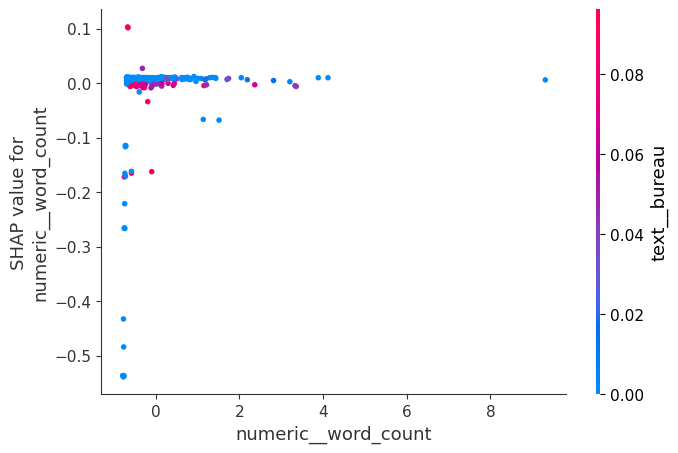

In [16]:
numeric_feature_names = [f for f in feature_names if f.startswith('numeric__')]
print("Available numeric features for dependence plots:", numeric_feature_names)

if numeric_feature_names:
    feature_to_check = numeric_feature_names[0]
    shap.dependence_plot(
        feature_to_check,
        shap_values[:, :, class_idx],   # <- same fix, class on last axis
        pd.DataFrame(
            X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray")
            else X_test_transformed,
            columns=feature_names
        ),
        show=False
    )
    plt.savefig(f"../images/shap_dependence_{feature_to_check.replace('numeric__', '')}.png",
                dpi=200, bbox_inches='tight')
    plt.show()

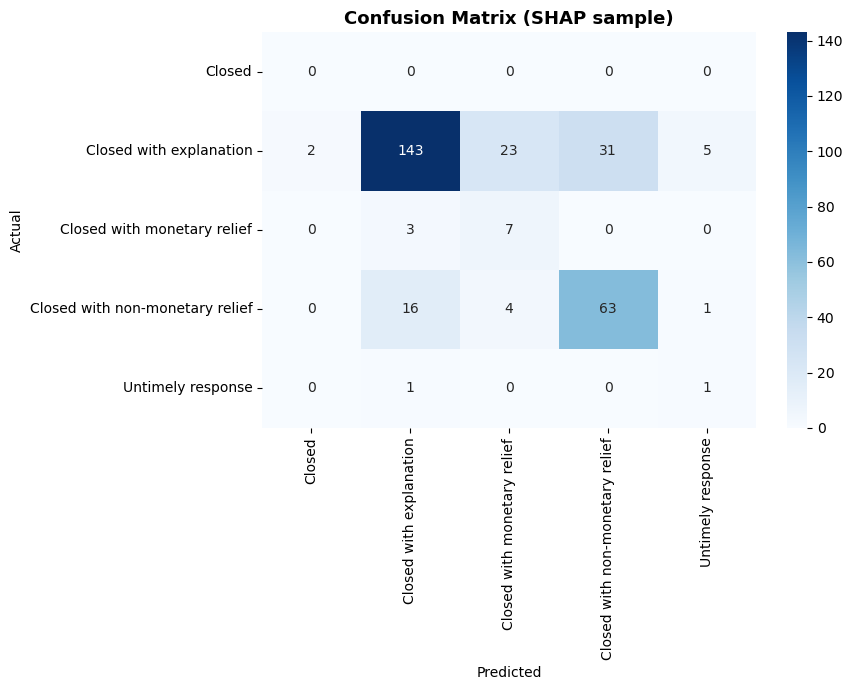

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels_sample, predictions_sample)
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title('Confusion Matrix (SHAP sample)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../images/confusion_matrix_shap_sample.png", dpi=200, bbox_inches='tight')
plt.show()